In [71]:
import matplotlib.pyplot as plt
import pickle
import numpy as np
from scipy import stats
import matplotlib
import os

# # Get the directory where the script is located
# script_dir = os.path.dirname(os.path.abspath(__file__))
# # Change to a relative directory from the script's location
# os.chdir(script_dir)

networks = ["k400", "ssv2"]
model_name = "slowfast_r50"

ROIList = ["V1", "pFS", "LO", "EBA", "MTSTS", "SMG", "behavior"]
condition = ["slow wo fusion", "slow", "fast"]

max_layer = np.zeros((len(condition), len(networks), len(ROIList)))
max_layer_indices = np.zeros((len(condition), len(networks), len(ROIList)), dtype=int)

for n, network in enumerate(networks):
    pretrained = "untrained/" if network == "untrained" else ""
    datas = "ssv2/" if network == "ssv2" else ""

    for c, cond in enumerate(condition):
        model_name = "slowfast_r50"
        
        # Loop through regions of interest
        for r, region in enumerate(ROIList):
            ttest_data = []

            if cond == "slow wo fusion":
                model_name = model_name.replace("slowfast_", "slow_")

            data = []

            folder = f"result/RSA/{datas}{pretrained}{model_name}/pearson/{region}/"
            if region == "behavior":
                with open(f"{folder}S02_all_dynamic_RSA.pkl", "rb") as File:
                    RSA = pickle.load(File)

                data = list(RSA.values())
                data = [tup[0] for tup in data]
            else:
                # Loop through subjects
                for sub in range(2, 18):
                    if sub == 8:
                        continue
                    subject = f"S{sub:02d}"

                    # Load RSA data from file
                    with open(f"{folder}{subject}_all_dynamic_RSA.pkl", "rb") as File:
                        RSA = pickle.load(File)
                    data.append([tup[0] for tup in list(RSA.values())])

            data = np.array(data)
            filtered_list = list(RSA.keys())

            if "slow" in model_name:
                # Filter RSA data based on the specified condition
                if cond == "slow" or cond == "slow wo fusion":
                    filtered_list = [
                        key for key in filtered_list if "multipathway_blocks.0" in key
                    ]
                elif cond == "fast":
                    filtered_list = [
                        key for key in filtered_list if "multipathway_blocks.1" in key
                    ]
                elif cond == "fusion":
                    filtered_list = [
                        key for key in filtered_list if "multipathway_fusion" in key
                    ]

            # Get the indices of selected keys
            indices = [
                index for index, key in enumerate(RSA.keys()) if key in filtered_list
            ]

            if region == "behavior":
                data = data[indices]
            else:
                data = data[:, indices]

                data = np.mean(data, axis=0)
            

            max_layer[c, n, r] = np.max(data)
            max_layer_indices[c, n, r] = np.argmax(data)

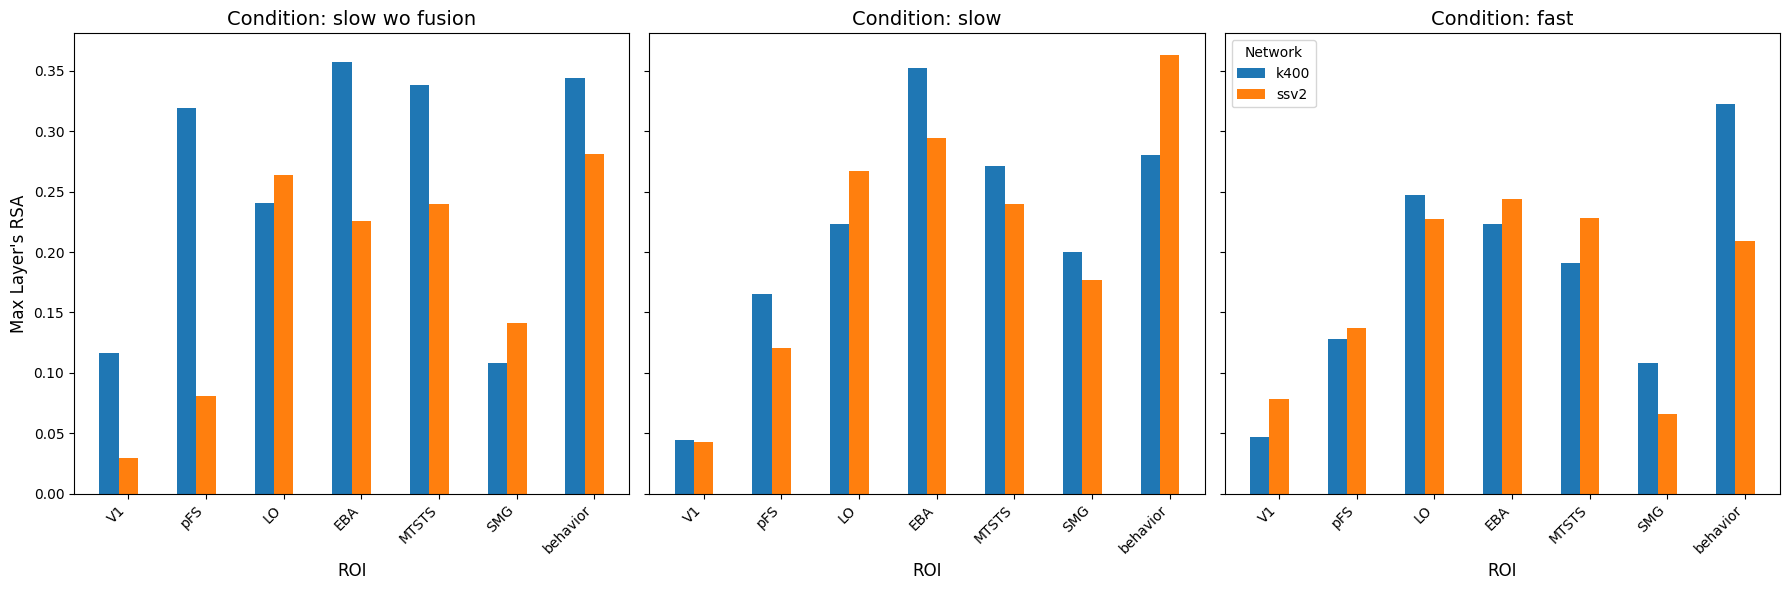

In [72]:
import numpy as np
import matplotlib.pyplot as plt

# Plot settings
num_conditions = len(condition)
num_rois = len(ROIList)
num_networks = len(networks)
width = 0.25  # Bar width
x = np.arange(num_rois)  # X positions for ROIs

# Create subplots: One per condition
fig, axes = plt.subplots(1, num_conditions, figsize=(18, 6), sharey=True)

for cond_idx, ax in enumerate(axes):
    data = max_layer[cond_idx, :, :]  # Data for the current condition (shape: (networks, ROIs))
    
    # Plot bars for each network
    for net_idx, network in enumerate(networks):
        ax.bar(x + net_idx * width, data[net_idx], width, label=network)
    
    # Customize each subplot
    ax.set_title(f'Condition: {condition[cond_idx]}', fontsize=14)
    ax.set_xticks(x + width)
    ax.set_xticklabels(ROIList, rotation=45, ha='right')
    ax.set_xlabel('ROI', fontsize=12)
    if cond_idx == 0:  # Add ylabel only to the first subplot
        ax.set_ylabel('Max Layer\'s RSA', fontsize=12)

# Add legend to the last subplot
axes[-1].legend(title='Network')

# Adjust layout
plt.tight_layout()
plt.show()

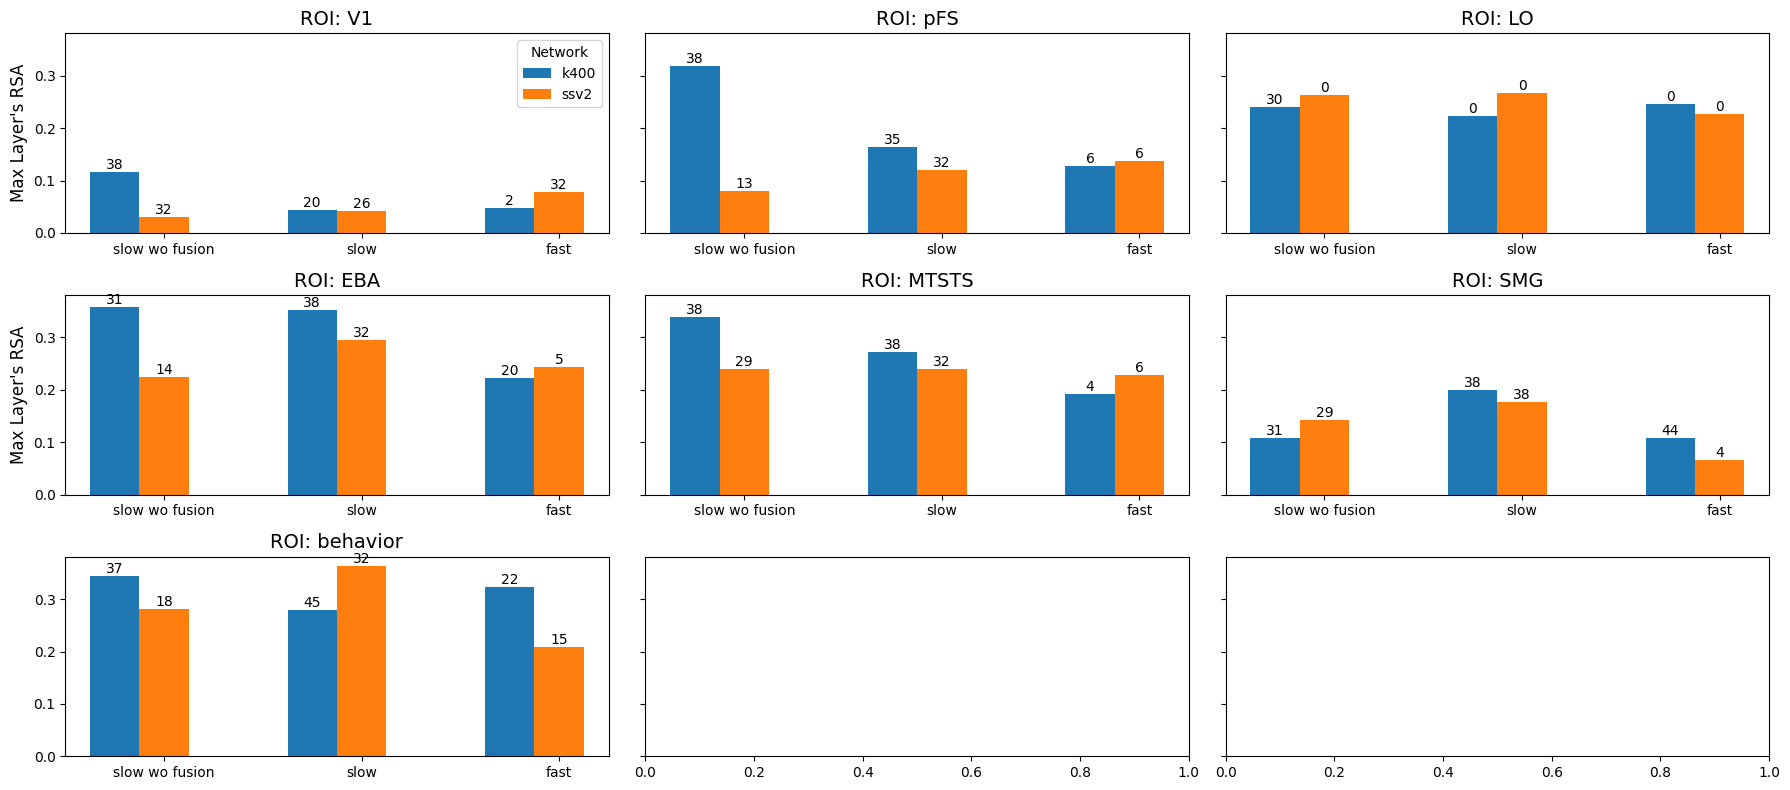

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# Plot settings
num_conditions = len(condition)
num_rois = len(ROIList)
num_networks = len(networks)
width = 0.25  # Bar width
x = np.arange(num_conditions)  # X positions for conditions

# Create subplots: One per condition
fig, axes = plt.subplots(3, num_rois // 2, figsize=(18, 8), sharey=True)
axes = axes.flatten()

for roi_idx, ax in enumerate(axes):
    if roi_idx >= 7:
        continue
    data = max_layer[:, :, roi_idx]  # Data for the current condition (shape: (networks, ROIs))
    indices = max_layer_indices[:, :, roi_idx]  # Indices for the current condition
    
    # Plot bars for each network
    for net_idx, network in enumerate(networks):
        bars = ax.bar(x + net_idx * width, data[:, net_idx], width, label=network)
        
        # Add text at the top of each bar
        for bar, index in zip(bars, indices[:, net_idx]):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height, f'{index}', ha='center', va='bottom')
    
    # Customize each subplot
    ax.set_title(f'ROI: {ROIList[roi_idx]}', fontsize=14)
    ax.set_xticks(x + width)
    ax.set_xticklabels(condition)
    if roi_idx == 0 or roi_idx == 3:  # Add ylabel only to the first subplot
        ax.set_ylabel('Max Layer\'s RSA', fontsize=12)

# Add legend to the first subplot
axes[0].legend(title='Network')

# Adjust layout
plt.tight_layout()
plt.show()

In [1]:
import matplotlib.pyplot as plt
import pickle
import numpy as np
from scipy import stats
import matplotlib
import os

# # Get the directory where the script is located
# script_dir = os.path.dirname(os.path.abspath(__file__))
# # Change to a relative directory from the script's location
# os.chdir(script_dir)

model_name = "dorsalnet"
ROIList = ["V1", "pFS", "LO", "EBA", "MTSTS", "SMG", "behavior"]

max_layer = np.zeros(len(ROIList))
max_layer_indices = np.zeros(len(ROIList))

# Loop through regions of interest
for r, region in enumerate(ROIList):
    ttest_data = []
    
    data = []

    folder = f"result/RSA/{model_name}/pearson/{region}/"
    if region == "behavior":
        with open(f"{folder}S02_all_dynamic_RSA.pkl", "rb") as File:
            RSA = pickle.load(File)

        data = list(RSA.values())
        data = [tup[0] for tup in data]
    else:
        # Loop through subjects
        for sub in range(2, 18):
            if sub == 8:
                continue
            subject = f"S{sub:02d}"

            # Load RSA data from file
            with open(f"{folder}{subject}_all_dynamic_RSA.pkl", "rb") as File:
                RSA = pickle.load(File)
            data.append([tup[0] for tup in list(RSA.values())])

    data = np.array(data)
    filtered_list = list(RSA.keys())

    # Get the indices of selected keys
    indices = [
        index for index, key in enumerate(RSA.keys()) if key in filtered_list
    ]

    if region == "behavior":
        data = data[indices]
    else:
        data = data[:, indices]

        data = np.mean(data, axis=0)

    max_layer[r] = np.max(data)
    max_layer_indices[r] = np.argmax(data)

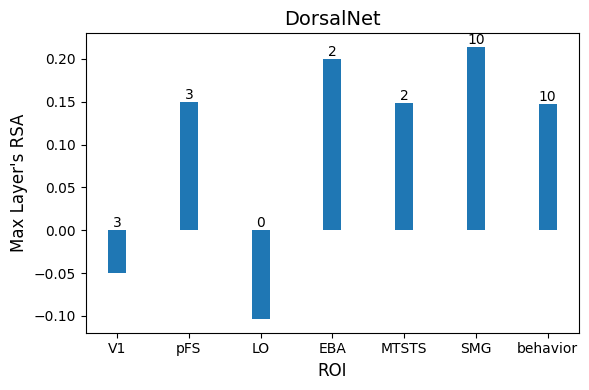

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Plot settings
num_rois = len(ROIList)
width = 0.25  # Bar width

x = np.arange(num_rois)  # X positions for ROIs

# Create a new figure
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(x, max_layer, width)

# Add text at the top of each bar
for bar, index in zip(bars, max_layer_indices):
    height = bar.get_height()
    height = max(0, height)
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{int(index)}', ha='center', va='bottom')

# Customize the plot
ax.set_title('DorsalNet', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(ROIList)
ax.set_xlabel('ROI', fontsize=12)
ax.set_ylabel('Max Layer\'s RSA', fontsize=12)

# Adjust layout
plt.tight_layout()
plt.show()